# Imports

In [1]:
from IPython.display import Image, display, SVG, HTML
from typing import Dict, List, Tuple, Generator, Optional, Callable, Literal
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed

# from interval_timeline import CallGraph
from scipy.signal import savgol_filter, medfilt
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
plt.rcParams['text.usetex'] = True
import seaborn as sns
import pandas as pd
import dask.dataframe as dd
import numpy as np
from numpy.lib.stride_tricks import as_strided
import os
import re
import time
import math
import datetime
import multiprocessing

from tqdm import tqdm
import otf2
import hatchet as ht
import thicket as tt
from collections import defaultdict

TEXLIVE_BIN_DIR = "/sw/frontier/spack-envs/base/opt/linux-sles15-x86_64/gcc-7.5.0/texlive-20220321-m56xupci4mc7hwbmnqy4oovch5pc7rrd/bin/x86_64-linux"
if TEXLIVE_BIN_DIR not in os.environ['PATH']:
    os.environ['PATH'] += os.pathsep + TEXLIVE_BIN_DIR
    print(f"Successfully added TexLive directory to PATH.")
else:
    print("TexLive directory was already in PATH.")


FONT_SIZE = 18
plt.rcParams.update({
    'font.size': FONT_SIZE,             # Controls default text sizes
    'axes.labelsize': FONT_SIZE * 0.95,        # Font size of the x and y labels
    'xtick.labelsize': FONT_SIZE * 0.9, # Font size for x-axis tick labels
    'ytick.labelsize': FONT_SIZE * 0.9, # Font size for y-axis tick labels
    'legend.fontsize': FONT_SIZE * 0.7,       # Font size of the legend
    'figure.titlesize': FONT_SIZE * 1.5 # Font size for the figure title
})

Successfully added TexLive directory to PATH.


In [2]:
# Track how long the notebook takes to run
NOTEBOOK_START_TIME = time.time()
print(f"Notebook started at {NOTEBOOK_START_TIME} ({datetime.datetime.fromtimestamp(NOTEBOOK_START_TIME)})")

Notebook started at 1766157702.318839 (2025-12-19 10:21:42.318839)


# Preamble

### Define The Name of the Cluster & Trace Paths

Define the name of the cluster and the paths to the trace files.
This is needed to parse the trace directory paths correctly as generated by the master run script.

In [3]:
STEP_VECTOR_SIZE = 134217728 # 2^27

### Define Which Ranks Run on Each Node

Define the topology of the runs. This is needed to attribute energy consumption correctly. Metrics are gathered at the node level, so we
need to know which node each rank ran on to get the metrics associated with that node + rank.

In [4]:
ACTIVE_PERIODS_MS = [1, 2, 5, 20, 50, 100, 200, 400, 1000]
IDLE_PERIODS_MS = ACTIVE_PERIODS_MS

DOUBLE_GCD_NODE_RANKS = {'node0': ['MPI Rank 0', 'MPI Rank 1', 'MPI Rank 2', 'MPI Rank 3', 'MPI Rank 4', 'MPI Rank 5', 'MPI Rank 6', 'MPI Rank 7']}
SINGLE_GCD_NODE_RANKS = {'node0': ['MPI Rank 0', 'MPI Rank 1', 'MPI Rank 2', 'MPI Rank 3']}
APU_NODE_RANKS = {'node0': ['MPI Rank 0', 'MPI Rank 1', 'MPI Rank 2', 'MPI Rank 3']}

### Define The Metrics to Attribute to Each Rank

This defines which MPI rank is on which GCD (frontier) or APU (el capitan). Two ranks drawing from the same GPU (each GPU has 2 GCDs) will have their energy consumption estimated independently based on their exclusive runtime.

In [5]:
DOUBLE_GCD_RANKS_TO_METRICS = {
	'MPI Rank 0': ['A2rocm_smi:::energy_count:device=0'],
	'MPI Rank 1': ['A2rocm_smi:::energy_count:device=1'],
	'MPI Rank 2': ['A2rocm_smi:::energy_count:device=2'],
	'MPI Rank 3': ['A2rocm_smi:::energy_count:device=3'],
}

SINGLE_GCD_RANKS_TO_METRICS = {
    'MPI Rank 0': ['A2rocm_smi:::energy_count:device=0'],
    'MPI Rank 1': ['A2rocm_smi:::energy_count:device=1'],
    'MPI Rank 2': ['A2rocm_smi:::energy_count:device=2'],
    'MPI Rank 3': ['A2rocm_smi:::energy_count:device=3']
}

APU_RANKS_TO_METRICS = {
    'MPI Rank 0': ['A2rocm_smi:::energy_count:device=0'],
    'MPI Rank 1': ['A2rocm_smi:::energy_count:device=1'],
    'MPI Rank 2': ['A2rocm_smi:::energy_count:device=2'],
    'MPI Rank 3': ['A2rocm_smi:::energy_count:device=3']
}

### Define Which Metrics to Track in the Traces

This defines the metrics we're going to pay attention to when parsing the traces.
All metrics that are used above must be included here.

In [6]:
METRICS_TO_TRACK = [
    'A2rocm_smi:::energy_count:device=0',
    'A2rocm_smi:::energy_count:device=1',
    'A2rocm_smi:::energy_count:device=2',
    'A2rocm_smi:::energy_count:device=3',
    'A2rocm_smi:::energy_count:device=4',
    'A2rocm_smi:::energy_count:device=6',

    'A2rocm_smi:::power_average:device=0:sensor=0',
    'A2rocm_smi:::power_average:device=2:sensor=0',
    'A2rocm_smi:::power_average:device=4:sensor=0',
    'A2rocm_smi:::power_average:device=6:sensor=0',

    'A2rocm_smi:::current_socket_power:device=0',
    'A2rocm_smi:::current_socket_power:device=1',
    'A2rocm_smi:::current_socket_power:device=2',
    'A2rocm_smi:::current_socket_power:device=3',

    'A2coretemp:::craypm:accel0_energy',
    'A2coretemp:::craypm:accel1_energy',
    'A2coretemp:::craypm:accel2_energy',
    'A2coretemp:::craypm:accel3_energy',
    
    'A2coretemp:::craypm:accel0_power',
    'A2coretemp:::craypm:accel1_power',
    'A2coretemp:::craypm:accel2_power',
    'A2coretemp:::craypm:accel3_power',
]

In [7]:
def calculate_steps_from_periods(time_active, time_sleep, time_desired=15000):
    # local time_active=$1
    # local time_sleep=$2
    # local nsteps=$((15000 / (time_active + time_sleep))) # Target ~15s total time
    return math.floor((time_desired + 1) / (time_active + time_sleep))  # Target ~15s total time

In [8]:
def get_trace_paths_for_step_variant(root_trace_dir: str, cluster_name: str, ranks: Optional[int]=None, convert=True) -> Dict[Tuple[int, int], List[str]]:
    if convert:
        for dirpath, dnames, filenames in tqdm(os.walk(root_trace_dir)):
            trace = os.path.join(dirpath, 'traces.otf2')
            if not os.path.exists(trace):
                continue
            if os.path.exists(os.path.join(dirpath, 'MPI Rank 0_Master_thread_callgraph.csv')) and os.path.exists(os.path.join(dirpath, 'MPI Rank 0_metrics.csv')):
                continue
            else:
                print(f"Converting trace to CSV: {trace}")
            cmd = f'source /lustre/orion/csc688/world-shared/scorep-amd/setup-env.sh > /dev/null 2>&1 && ./trace_to_csv_parallel --trace={trace} --metrics="{",".join(METRICS_TO_TRACK)}" --outputDir={dirpath} > /dev/null 2>&1'
            if os.system(cmd):
                print(f'Error running command: {cmd}')
                print(f"Error converting trace: {trace}")
        
    result = {}
    # Instead, just iterate through all the traces and add them based on their time active and idle
    for d in os.listdir(f"{root_trace_dir}/"):
        # Get the time_active and time_idle from the directory name
        pattern = rf"step_function-{'r' + str(ranks) + '-' if ranks else ''}--vector_size_{STEP_VECTOR_SIZE}_--n_steps_(\d+)_--time_active_(\d+)_--time_sleep_(\d+)"
        match = re.match(pattern, d)
        if match:
            n_steps = int(match.group(1))
            time_active = int(match.group(2))
            time_idle = int(match.group(3))
            trace_dir = f"{root_trace_dir}/{d}"
            for subdir in os.listdir(trace_dir):
                if re.match(rf"trial_\d+-{cluster_name}\d+-.*step_function-.*", subdir) and os.path.isdir(os.path.join(trace_dir, subdir)):
                    key = (time_active, time_idle)
                    if key not in result:
                        result[key] = []
                    result[key].append(os.path.join(trace_dir, subdir))
                # else:
                #     print(f"Subdirectory {subdir} did not match expected pattern.")
        # else:
        #     print(f"Directory {d} did not match expected pattern: {pattern}.")
    return result

DOUBLE_GCD_TRACES = get_trace_paths_for_step_variant('/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-128-node-results', 'frontier', ranks=8, convert=False)
SINGLE_GCD_TRACES = get_trace_paths_for_step_variant('/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-128-node-results', 'frontier', ranks=4, convert=False)
APU_TRACES = get_trace_paths_for_step_variant('/lustre/orion/csc688/world-shared/results-mi300a-organized', 'parrypeak', convert=False)
print("Finished gathering trace paths.")

print("SINGLE_GCD_TRACES:", len(SINGLE_GCD_TRACES))
print("DOUBLE_GCD_TRACES:", len(DOUBLE_GCD_TRACES))
print("APU_TRACES:", len(APU_TRACES))

Finished gathering trace paths.
SINGLE_GCD_TRACES: 100
DOUBLE_GCD_TRACES: 100
APU_TRACES: 100


### Metrics
Which metrics to trace, and functions for reading/writing them to CSVs.

In [9]:
def metrics_to_csv(group: str, thread_metrics: Dict[str, List[Tuple[float, float]]], filename: str):
    """Convert metrics to a CSV file."""
    with open(filename, 'w') as f:
        f.write("Group,Metric Name,Time,Value\n")
        for metric_name, values in thread_metrics.items():
            for time, value in values:
                f.write(f"{group},{metric_name},{time},{value}\n")

def read_metrics_dataframe(file: str) -> pd.DataFrame:
    dtype_map = {
        'Group': 'category',
        'Metric Name': 'category',
        'Time': 'float64',
        'Value': 'int64' # Int64 for precision
    }
    df = pd.read_csv(file, dtype=dtype_map)
    df = df[df['Metric Name'].isin(METRICS_TO_TRACK)]
    # For all the rocm metrics, divide by 1e6 to convert from uJ to J
    for metric_name in df['Metric Name'].unique():
        if 'rocm_smi:::energy_count:device' in metric_name or 'rocm_smi:::power_average:device' in metric_name or 'rocm_smi:::current_socket_power:device' in metric_name:
            df['Value'] = df['Value'].astype(float)
            df['Value'] = df['Value'].fillna(0.0)
            df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000
    return df

def read_call_graph_dataframe(file: str) -> pd.DataFrame:
    dtype_map = {
        'Thread': 'category',
        'Group': 'category',
        'Depth': 'uint32',
        'Name': 'category',
        'Start Time': 'float64',
        'End Time': 'float64',
        'Duration': 'float64'
    }
    return pd.read_csv(file, dtype=dtype_map)


In [10]:
def sampled_to_continuous(df, time_col='Time', value_col='Value', linear_interpolate=True):
    t_samples = df[time_col].astype(float)
    y = df[value_col].astype(float)
    if linear_interpolate:
        f = lambda t: np.interp(t, t_samples, y)
    else:
        f = lambda t: y.iloc[np.searchsorted(t_samples, t, side='right') - 1].values
    return f

def numerical_derivative(func, h=1e-5):
    return lambda t: (func(t + h) - func(t - h)) / (2 * h)

def numerical_integral(f, a=0.0, dx=1e-1):
    try:
        _ = f(np.array([a, a + dx]))
        f_np = f
    except Exception:
        f_np = np.vectorize(f)
    
    def F(x):
        x_arr = np.atleast_1d(x).astype(float)
        sign = np.ones_like(x_arr)
        mask = x_arr < a
        sign[mask] = -1
        x_pos = np.where(mask, a + (a - x_arr), x_arr)
        
        xmax = x_pos.max()
        t = np.arange(a, xmax + dx, dx)
        u = f_np(t)
        
        trap_heights = (u[:-1] + u[1:]) / 2
        cum = np.concatenate(([0], np.cumsum(trap_heights * dx)))
        
        idx = ((x_pos - a) // dx).astype(int)
        rem = x_pos - (a + idx * dx)
        
        f_end = f_np(x_pos)
        f_start = u[idx]
        
        integral = cum[idx] + (f_start + f_end) * rem / 2
        result = sign * integral
        
        return result.item() if np.isscalar(x) else result
    
    return F
        
def continuous_savgol_filter(f, window_length=11, polyorder=2, sample_rate=0.001):
    def f_smooth(t):
        t = np.asarray(t)
        t_min = t.min()
        t_max = t.max()
        t_samples = np.arange(t_min, t_max + sample_rate, sample_rate)
        y_samples = f(t_samples)
        y_smooth = savgol_filter(y_samples, window_length=window_length, polyorder=polyorder, mode='nearest')
        return np.interp(t, t_samples, y_smooth)
    return f_smooth
        
def continuous_median_filter(f, kernel_size=11, sample_rate=0.001):
    def f_smooth(t):
        t = np.asarray(t)
        t_min = t.min()
        t_max = t.max()
        t_samples = np.arange(t_min, t_max + sample_rate, sample_rate)
        y_samples = f(t_samples)
        y_smooth = medfilt(y_samples, kernel_size=kernel_size)
        return np.interp(t, t_samples, y_smooth)
    return f_smooth        

def continuous_moving_average(f, window_size=1.0, sample_rate=0.001):
    def f_smooth(t):
        t = np.asarray(t)
        t_min = t.min()
        t_max = t.max()
        t_samples = np.arange(t_min, t_max + sample_rate, sample_rate)
        y_samples = f(t_samples)
        
        cumsum = np.cumsum(np.insert(y_samples, 0, 0)) 
        window_length = int(window_size / sample_rate)
        window_length = max(1, window_length)  # Ensure at least size 1
        y_smooth = (cumsum[window_length:] - cumsum[:-window_length]) / window_length
        
        pad_size = len(y_samples) - len(y_smooth)
        y_smooth = np.concatenate((np.full(pad_size, y_smooth[0]), y_smooth))
        
        return np.interp(t, t_samples, y_smooth)
    return f_smooth

def continuous_exponential_moving_average_filter(f, alpha=0.5, sample_rate=0.001):
    def f_smooth(t):
        t = np.asarray(t)
        t_min = t.min()
        t_max = t.max()
        t_samples = np.arange(t_min, t_max + sample_rate, sample_rate)
        y_samples = f(t_samples)
        
        y_smooth = np.zeros_like(y_samples)
        y_smooth[0] = y_samples[0]
        for i in range(1, len(y_samples)):
            y_smooth[i] = alpha * y_samples[i] + (1 - alpha) * y_smooth[i - 1]
        
        return np.interp(t, t_samples, y_smooth)
    return f_smooth

def sliding_window_view(x, window_shape):
    x = np.asarray(x)
    if window_shape > x.shape[0]:
        raise ValueError("window_shape must be less than or equal to the size of the array")
    shape = (x.shape[0] - window_shape + 1, window_shape)
    strides = (x.strides[0], x.strides[0])
    return as_strided(x, shape=shape, strides=strides)

def continuous_interquartile_range_filter(f, window_size=1.0, sample_rate=0.001):
    def f_smooth(t):
        t = np.asarray(t)
        t_min = t.min()
        t_max = t.max()
        t_samples = np.arange(t_min, t_max + sample_rate, sample_rate)
        y_samples = f(t_samples).astype(float)

        n = len(y_samples)
        if n == 0:
            return np.interp(t, t_samples, y_samples)

        # Compute window length in samples and clamp to [1, n]
        window_length = int(round(window_size / sample_rate))
        window_length = max(1, min(window_length, n))

        # Make window odd for symmetry (not strictly required)
        if window_length % 2 == 0 and window_length > 1:
            window_length += 1
            if window_length > n:
                window_length = n

        half = window_length // 2

        # Pad edges so the output has same length as input
        y_padded = np.pad(y_samples, (half, half), mode='edge')

        # Create sliding windows: shape (n, window_length)
        windows = sliding_window_view(y_padded, window_length)

        # Compute Q1 and Q3 along window axis and average
        q1 = np.percentile(windows, 25, axis=1)
        q3 = np.percentile(windows, 75, axis=1)
        y_smooth = 0.5 * (q1 + q3)

        return np.interp(t, t_samples, y_smooth)

    return f_smooth

def unwrap_or_zero(f):
    if not f:
        return 0.0
    else:
        return f


### Thicket + Hatchet Integration
Convert the CSV datasets into thicket/hatchet objects for analysis

In [11]:
def create_hatchet_dag(call_graph_df: pd.DataFrame, metric_functions: Dict[str, callable]):
    df = call_graph_df.copy()
    df = df.sort_values(by='Start Time')
    df = df[df['Duration'] >= 0.001]

    pref3 = df['Name'].str[:3].str.lower()
    df = df[~pref3.isin(['hip', 'mpi'])]
    starts = df['Start Time'].to_numpy()
    ends   = df['End Time'].to_numpy()
    names  = df['Name'].to_numpy()
    depths = df['Depth'].to_numpy()
    durs   = df['Duration'].to_numpy()


    metrics_cols = {}
    for metric, f in tqdm(metric_functions.items()):
        try:
            vals = f(ends) - f(starts)
            vals = np.asarray(vals, dtype=float)
            vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)
        except Exception:
            vals = np.fromiter(
                (unwrap_or_zero(f(e) - f(s)) for s, e in zip(starts, ends)),
                dtype=float, count=len(starts)
            )
        metrics_cols[metric] = vals

    dag_roots: list = []
    last_at_depth: dict[int, dict] = {}

    M = len(df)
    for i, (name, depth, dur) in enumerate(zip(names, depths, durs)):
        node_metrics = {'time (inc)': float(dur), 'time': 0.0}
        for m, arr in metrics_cols.items():
            node_metrics[m] = float(arr[i])

        node = {'frame': {'name': name}, 'metrics': node_metrics, 'children': []}

        if depth == 0 or (depth - 1) not in last_at_depth:
            dag_roots.append(node)
        else:
            parent = last_at_depth[depth - 1]
            parent['children'].append(node)

        last_at_depth[depth] = node

    stack = [(root, False) for root in dag_roots]
    while stack:
        node, visited = stack.pop()
        if not visited:
            stack.append((node, True))
            for ch in node['children']:
                stack.append((ch, False))
        else:
            child_incs = 0.0
            for ch in node['children']:
                child_incs += ch['metrics']['time (inc)']
            node['metrics']['time'] = node['metrics']['time (inc)'] - child_incs

    return dag_roots

# Hierarchical DataFrames

Organize the data into hierarchical dataframes for easier analysis:
- `Ensemble`: all the runs of a given configuration
- `Run`: a single run of a configuration
- `Node`: a single node in a run
- `Rank`: a single MPI rank in a node

In [12]:
class Rank:
    def __init__(self, node: str, name: str, call_graph: pd.DataFrame):
        self.node = node
        self.name = name
        self.call_graph = call_graph
        assert self.call_graph.columns.tolist() == ['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'], f"Call graph DataFrame has incorrect columns, found {call_graph.columns.tolist()}"
        
    def get_all_code_regions(self) -> List[str]:
        return self.call_graph['Name'].unique().tolist()

    def compute_attribution(
        self,
        metrics_accumulated: Dict[str, callable],
        duration_threshold: float = 0.001,
        weights_by_metric: Optional[Dict[str, np.ndarray]] = None):
        df = self.call_graph
        df = df[df['Duration'] >= duration_threshold]
        pref3 = df['Name'].str[:3].str.lower()
        df = df[~pref3.isin(['hip', 'mpi'])]

        if df.empty:
            return pd.DataFrame(columns=['Code Region'] + list(metrics_accumulated.keys()))

        starts = df['Start Time'].to_numpy()
        ends   = df['End Time'].to_numpy()
        names  = df['Name'].to_numpy()

        cols = {}
        for metric, f in metrics_accumulated.items():
            try:
                deltas = f(ends) - f(starts)
                deltas = np.asarray(deltas, dtype=float)
                deltas = np.nan_to_num(deltas, nan=0.0, posinf=0.0, neginf=0.0)
            except Exception:
                deltas = np.fromiter(
                    (unwrap_or_zero(f(e) - f(s)) for s, e in zip(starts, ends)),
                    dtype=float, count=len(starts)
                )

            if weights_by_metric and metric in weights_by_metric:
                w = np.asarray(weights_by_metric[metric], dtype=float)
                if w.shape[0] == deltas.shape[0]:
                    deltas = deltas * w
                elif w.size == 1:
                    deltas = deltas * float(w)
                else:
                    deltas = deltas * 1.0

            cols[metric] = deltas

        out = pd.DataFrame(cols)
        out['Code Region'] = names
        out = out.groupby('Code Region', as_index=False).sum()
        return out

    def refresh(self):
        return Rank(self.node, self.name, self.call_graph)

    def __str__(self):
        return f"Rank({self.name})"

def build_inclusive_masks_for_rank(breaks, s, e, names, depths):
    """
    For each segment [breaks[i], breaks[i+1]), return a dict:
      masks[region_name][i] = True  iff the region is on the call stack
                                   (ancestor of top-of-stack) for the ENTIRE segment.
    Assumptions:
      - breaks includes all start/end times (so inside a segment no boundary occurs).
      - 'depths' is 0-based, increasing with nesting.
    """
    seg_count = breaks.size - 1
    masks = defaultdict(lambda: np.zeros(seg_count, dtype=bool))

    lefts, rights = breaks[:-1], breaks[1:]
    for i in range(seg_count):
        L, R = lefts[i], rights[i]

        # Regions that cover the whole segment (active across the entire segment)
        idx = np.where((s <= L) & (e >= R))[0]
        if idx.size == 0:
            continue

        # Top of stack depth
        dmax = depths[idx].max()

        # Inclusive chain = exactly one region per depth 0..dmax that covers the whole segment
        # (there should typically be at most one per depth due to proper nesting)
        for d in range(dmax + 1):
            cand = idx[depths[idx] == d]
            if cand.size:
                # If instrumentation duplicates exist at same depth, pick the one that covers the segment;
                # here cand already covers segment; pick the first deterministically.
                j = cand[0]
                masks[names[j]][i] = True

    return masks

class Node:
    def __init__(self, name: str, metrics_df: pd.DataFrame, ranks: List[Rank]):
        self.name = name
        self.ranks = ranks
        self.metrics = metrics_df
        assert self.metrics.columns.tolist() == ['Group', 'Metric Name', 'Time', 'Value'], f"Metrics DataFrame has incorrect columns, found {metrics_df.columns.tolist()}"

    def refresh(self):
        return Node(self.name, self.metrics, [rank.refresh() for rank in self.ranks])

    def get_metric_names(self) -> List[str]:
        return self.metrics['Metric Name'].unique().tolist()
    
    def get_metric_samples(self, metric_name: str) -> pd.DataFrame:
        return self.metrics[self.metrics['Metric Name'] == metric_name]

    def _filtered_callgraph(self, rank: Rank, duration_threshold: float):
        df = rank.call_graph
        df = df[df['Duration'] >= duration_threshold]
        pref3 = df['Name'].str[:3].str.lower()
        # df = df[~pref3.isin(['hip', 'mpi'])]
        # Finite and non-degenerate
        mfin = np.isfinite(df['Start Time']) & np.isfinite(df['End Time'])
        df = df[mfin & (df['End Time'] > df['Start Time'])]
        return df

    # ---- NEW CORE HELPER: inclusive vs exclusive controlled by flag ----
    def _compute_attribution_core(
        self,
        ranks_to_metrics: Dict[str, List[str]],
        instantaneous_metrics = [],
        duration_threshold: float = 0.0,
        inclusive: bool = True,
    ):
        used_metrics = sorted({m for ml in ranks_to_metrics.values() for m in ml})
        if not used_metrics:
            return pd.DataFrame(columns=['Code Region'])

        metrics_continuous = {m: sampled_to_continuous(self.get_metric_samples(m)) for m in used_metrics}
        metrics_accumulated = {
            m: (numerical_integral(metrics_continuous[m]) if m in instantaneous_metrics else metrics_continuous[m])
            for m in used_metrics
        }

        rank_df = {r.name: self._filtered_callgraph(r, duration_threshold) for r in self.ranks}
        rank_events = {
            rname: (
                df['Start Time'].to_numpy(),
                df['End Time'].to_numpy(),
                df['Name'].to_numpy(),
                df['Depth'].astype(int).to_numpy()
            )
            for rname, df in rank_df.items()
        }

        metric_to_ranks: Dict[str, List[str]] = {}
        for rname, mlist in ranks_to_metrics.items():
            for m in mlist:
                metric_to_ranks.setdefault(m, []).append(rname)

        rank_tables: Dict[str, Dict[str, Dict[str, float]]] = {r.name: {} for r in self.ranks}

        for metric in used_metrics:
            f = metrics_accumulated[metric]
            rnames = [rn for rn in metric_to_ranks.get(metric, []) if rn in rank_events]
            if not rnames:
                continue

            all_s, all_e = [], []
            for rn in rnames:
                s, e, _, _ = rank_events[rn]
                if s.size:
                    all_s.append(s); all_e.append(e)
            if not all_s:
                continue

            S_concat = np.concatenate(all_s)
            E_concat = np.concatenate(all_e)
            breaks = np.unique(np.concatenate([S_concat, E_concat]))
            breaks = breaks[np.isfinite(breaks)]
            if breaks.size < 2:
                continue
            seg_count = breaks.size - 1

            # dE per segment
            try:
                E_vals = f(breaks)
                E_vals = np.asarray(E_vals, dtype=float)
                if E_vals.shape != breaks.shape:
                    raise ValueError
            except Exception:
                print(f"Warning: Non-vectorized metric function for metric {metric}, falling back to loop.")
                E_vals = np.array([float(f(float(t))) for t in breaks], dtype=float)

            dE = E_vals[1:] - E_vals[:-1]
            dE = np.nan_to_num(dE, nan=0.0, posinf=0.0, neginf=0.0)
            dE = np.maximum(dE, 0.0)

            # Which ranks are active in each segment?
            active_by_rank: Dict[str, np.ndarray] = {}
            lr_by_rank: Dict[str, Tuple[np.ndarray, np.ndarray]] = {}

            zeros_seg = np.zeros(seg_count, dtype=bool)
            for rn in rnames:
                s, e, _, _ = rank_events[rn]
                if s.size == 0:
                    active_by_rank[rn] = zeros_seg
                    lr_by_rank[rn] = (np.empty(0, dtype=int), np.empty(0, dtype=int))
                    continue

                L = np.searchsorted(breaks, s, side='right') - 1
                R = np.searchsorted(breaks, e, side='left') - 1
                valid = (R >= L) & (R >= 0) & (L < seg_count)
                L = np.clip(L[valid], 0, seg_count - 1)
                R = np.clip(R[valid], 0, seg_count - 1)

                lr_by_rank[rn] = (L, R)

                # coverage count via difference array
                diff = np.zeros(seg_count + 1, dtype=int)
                for l, r in zip(L, R):
                    diff[l] += 1
                    diff[r + 1] -= 1
                c = np.cumsum(diff[:-1])
                active_by_rank[rn] = (c > 0)

            # k(t): number of active ranks per segment
            k = np.zeros(seg_count, dtype=int)
            for rn in rnames:
                k += active_by_rank[rn].astype(int)

            # Energy share per segment for each rank: ΔE/k (if k==0, remains unattributed)
            share_per_seg = np.zeros_like(dE, dtype=float)
            mask_k = (k > 0)
            share_per_seg[mask_k] = dE[mask_k] / k[mask_k]

            # --- Attribution per rank ---
            for rn in rnames:
                s, e, names, depths = rank_events[rn]
                if s.size == 0:
                    continue

                L, R = lr_by_rank[rn]
                if L.size == 0:
                    continue

                if inclusive:
                    masks: Dict[str, np.ndarray] = defaultdict(lambda: np.zeros(seg_count, dtype=bool))
                    for j in range(L.size):
                        l = L[j]; r = R[j]
                        if r < l:
                            continue
                        masks[names[j]][l:r+1] = True

                    for region_name, seg_mask in masks.items():
                        if not seg_mask.any():
                            continue
                        contrib = float(share_per_seg[seg_mask].sum())
                        if contrib == 0.0:
                            continue
                        tbl = rank_tables[rn].setdefault(region_name, {})
                        tbl[metric] = tbl.get(metric, 0.0) + contrib
                else:
                    top_depth = np.full(seg_count, -1, dtype=int)
                    top_idx   = np.full(seg_count, -1, dtype=int)

                    # For each event j, mark segments [L[j], R[j]] and keep the deepest
                    for j in range(L.size):
                        l = L[j]; r = R[j]
                        if r < l:
                            continue
                        d = depths[j]
                        seg_slice = slice(l, r + 1)

                        current_depths = top_depth[seg_slice]
                        mask = d >= current_depths
                        if not np.any(mask):
                            continue

                        # Update depths
                        current_depths[mask] = d
                        top_depth[seg_slice] = current_depths

                        # Update indices
                        current_idx = top_idx[seg_slice]
                        current_idx[mask] = j
                        top_idx[seg_slice] = current_idx

                    # Now attribute share_per_seg only to top-of-stack region per segment
                    for seg_i, j in enumerate(top_idx):
                        if j < 0:
                            continue  # rank not active here
                        contrib = float(share_per_seg[seg_i])
                        if contrib == 0.0:
                            continue
                        region_name = names[j]
                        tbl = rank_tables[rn].setdefault(region_name, {})
                        tbl[metric] = tbl.get(metric, 0.0) + contrib

        # --- Convert to per-rank DataFrames and do a wide merge ---
        attribution = None
        for rank in self.ranks:
            rn = rank.name
            # Filter only the metrics requested for this rank
            wanted = ranks_to_metrics.get(rn, [])
            if not wanted:
                continue

            rows = []
            for region, mdict in rank_tables.get(rn, {}).items():
                row = {'Code Region': region}
                # Ensure a column for each requested metric
                for m in wanted:
                    row[m] = mdict.get(m, 0.0)
                rows.append(row)

            df_rank = pd.DataFrame(rows) if rows else pd.DataFrame({'Code Region': []})
            # Ensure columns if they are missing
            for m in wanted:
                if m not in df_rank.columns:
                    df_rank[m] = 0.0

            # Rename metrics with rank suffix to avoid collisions
            rename_map = {m: f"{m}_{rn}" for m in wanted}
            df_rank = df_rank.rename(columns=rename_map)

            # Outer merge on 'Code Region'
            attribution = df_rank if attribution is None else pd.merge(
                attribution, df_rank, on='Code Region', how='outer'
            )

        # If there was nothing, return minimal header
        if attribution is None:
            all_cols = ['Code Region'] + [f"{m}_{r.name}" for r, ml in ranks_to_metrics.items() for m in ml]
            return pd.DataFrame(columns=all_cols)

        return attribution.fillna(0.0)

    def compute_attribution(
        self,
        ranks_to_metrics: Dict[str, List[str]] = {},
        instantaneous_metrics = [],
        duration_threshold: float = 0.001,
    ):
        return self._compute_attribution_core(
            ranks_to_metrics=ranks_to_metrics,
            instantaneous_metrics=instantaneous_metrics,
            duration_threshold=duration_threshold,
            inclusive=True,
        )

    def compute_attribution_exclusive(
        self,
        ranks_to_metrics: Dict[str, List[str]] = {},
        instantaneous_metrics = [],
        duration_threshold: float = 0.001,
    ):
        """
        Exclusive attribution: for each segment and rank, only the *deepest*
        active region on the stack receives that segment's share of energy.
        """
        return self._compute_attribution_core(
            ranks_to_metrics=ranks_to_metrics,
            instantaneous_metrics=instantaneous_metrics,
            duration_threshold=duration_threshold,
            inclusive=False,
        )

    def __str__(self):
        return f"Node(name={self.name}, ranks={[rank.name for rank in self.ranks]})"

class Run:
    def __init__(self, path: str, nodes: List[Node] = []):
        self.path = path
        self.nodes = nodes
        
    def refresh(self):
        return Run(self.path, [node.refresh() for node in self.nodes])

    @staticmethod
    def from_trace_path(trace_path: str, node_ranks: Dict[str, List[str]]):
        # Load the trace dataframes for each node and its ranks
        if not os.path.exists(trace_path):
            raise FileNotFoundError(f"Trace file {trace_path} does not exist.")
        # print(f"Loading trace from {trace_path} for idle period {idle_period_ms} ms and active period {active_period_ms} ms.")
        # trace_to_csv(trace_path, processes, METRICS_TO_TRACK)
        # Load the CSV files into dataframes
        all_threads = []
        for _, ranks in node_ranks.items():
            all_threads.extend(ranks)
        result = {}
        # trace_to_csv(trace_path, all_threads, METRICS_TO_TRACK)
        for node, ranks in node_ranks.items():
            if not os.path.exists(os.path.join(trace_path, f"{ranks[0]}_metrics.csv")):
                raise FileNotFoundError(f"Metrics file for rank {ranks[0]} does not exist in trace path {trace_path}.")
            metrics_df = read_metrics_dataframe(os.path.join(trace_path, f"{ranks[0]}_metrics.csv"))
            # print(f"Loaded metrics dataframe from {trace_path}")
            assert metrics_df.columns.tolist() == ['Group', 'Metric Name', 'Time', 'Value'], f"Metrics DataFrame has incorrect columns, found {metrics_df.columns.tolist()}"
            rank_callgraphs = []
            for rank in ranks:
                if os.path.exists(os.path.join(trace_path, f"{rank}_Master_thread_callgraph.csv")):
                    call_graph = read_call_graph_dataframe(os.path.join(trace_path, f"{rank}_Master_thread_callgraph.csv"))
                    assert call_graph.columns.tolist() == ['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'], f"Call graph DataFrame has incorrect columns, found {call_graph.columns.tolist()}"
                    # Construct the Hatchet and Thicket graphs
                    rank_callgraphs.append(Rank(node, rank, call_graph))
                else:
                    raise FileNotFoundError(f"Call graph file for rank {rank} does not exist in trace path {trace_path}.")
            result[node] = Node(node, metrics_df, rank_callgraphs)
        return Run(trace_path, list(result.values()))

    def compute_attribution(self, ranks_to_metrics: Dict[str, List[str]]={}, instantaneous_metrics=[]):
        attributions = {}
        for node in self.nodes:
            # print(f"Computing attribution for node {node.name}...")
            attributions[node.name] = node.compute_attribution(ranks_to_metrics, instantaneous_metrics)
        return attributions
    
    def compute_attribution_exclusive(self, ranks_to_metrics: Dict[str, List[str]] = {}, instantaneous_metrics = []):
        attributions = {}
        for node in self.nodes:
            # print(f"Computing EXCLUSIVE attribution for node {node.name}...")
            attributions[node.name] = node.compute_attribution_exclusive(
                ranks_to_metrics,
                instantaneous_metrics,
            )
        return attributions
    
    def get_metric_samples(self, node_name: str, metric_name: str) -> pd.DataFrame:
        for node in self.nodes:
            if node.name == node_name:
                return node.get_metric_samples(metric_name)
        raise ValueError(f"Node {node_name} not found in run.")
    
    def to_thicket(self, **metadata) -> tt.Thicket:
        thickets = []
        
        for node in self.nodes:
            # self.get_metric_samples(node)
            metric_functions = {}
            for metric_name in node.get_metric_names():
                metric_functions[metric_name] = sampled_to_continuous(node.get_metric_samples(metric_name))
            
            for rank in node.ranks:
                print(f"Creating Thicket for node {node.name}, rank {rank.name}...")
                dag = create_hatchet_dag(rank.call_graph, metric_functions)
                tf = tt.Thicket.from_literal(dag)
                # tf = tt.Thicket.from_literal(dag)
                print("Thicket created from DAG.")
                tf.metadata = pd.DataFrame.from_dict(tf.profile_mapping, orient="index")
                tf.metadata['rank'] = rank.name
                tf.metadata['node'] = node.name
                tf.metadata = tf.metadata.assign(**metadata)
                tf.metadata.index.name = tf.dataframe.index.names[1]
        
                thickets.append(tf)
        
        print(f"Total thickets created: {len(thickets)}")
        if thickets:
            print("Combining thickets...")
            return tt.Thicket.concat_thickets(thickets, disable_tqdm=True)
        raise ValueError("No thickets were created from the run.")
        
    def __str__(self):
        return f"Run(path={self.path}, nodes={[str(node) for node in self.nodes]})"

class Ensemble:
    def __init__(self, runs: List[Run]):
        self.runs = runs
        self.attributions = {}
        self.attributions_exclusive = {}
    
    @staticmethod
    def from_trace_paths(trace_paths: List[str], node_ranks: Dict[str, List[str]]):
        return ensemble_from_trace_path_helper(trace_paths, node_ranks)
 
    def refresh(self):
        return Ensemble([run.refresh() for run in self.runs])
    
    def compute_attribution(self, ranks_to_metrics: Dict[str, List[str]]={}, instantaneous_metrics=[]):
        if self.attributions != {}:
            print("Attributions already computed, returning cached results.")
            return self.attributions
        
        for run in self.runs:
            self.attributions[os.path.basename(os.path.dirname(run.path))] = run.compute_attribution(ranks_to_metrics, instantaneous_metrics)
        return self.attributions
 
    def compute_attribution_across_runs(self, ranks_to_metrics: Dict[str, List[str]] = {}, instantaneous_metrics = []):
        attributions = self.compute_attribution(ranks_to_metrics, instantaneous_metrics)
        if not attributions:
            return pd.DataFrame(columns=['Run', 'Node', 'Code Region', 'Metric', 'Value'])

        records = []
        for run_name, node_attribs in attributions.items():
            for node_name, df in node_attribs.items():
                if df is None or df.empty: 
                    continue
                code = df['Code Region'].to_numpy()
                for metric in df.columns:
                    if metric == 'Code Region': 
                        continue
                    vals = df[metric].to_numpy()
                    # Extend in bulk (no per-iteration concatenations)
                    records.extend(
                        {'Run': run_name, 'Node': node_name, 'Code Region': c, 'Metric': metric, 'Value': v}
                        for c, v in zip(code, vals)
                    )
        return pd.DataFrame.from_records(records)

    def compute_attribution_exclusive(self, ranks_to_metrics: Dict[str, List[str]] = {}, instantaneous_metrics = []):
        if self.attributions_exclusive != {}:
            print("Exclusive attributions already computed, returning cached results.")
            return self.attributions_exclusive
        
        for run in self.runs:
            run_name = os.path.basename(os.path.dirname(run.path))
            print(f"Computing EXCLUSIVE attribution for run {run_name}...")
            self.attributions_exclusive[run_name] = run.compute_attribution_exclusive(
                ranks_to_metrics,
                instantaneous_metrics,
            )
        return self.attributions_exclusive

    def compute_attribution_exclusive_across_runs(
        self,
        ranks_to_metrics: Dict[str, List[str]] = {},
        instantaneous_metrics = [],
    ):
        attributions = self.compute_attribution_exclusive(ranks_to_metrics, instantaneous_metrics)
        if not attributions:
            return pd.DataFrame(columns=['Run', 'Node', 'Code Region', 'Metric', 'Value'])

        records = []
        for run_name, node_attribs in attributions.items():
            for node_name, df in node_attribs.items():
                if df is None or df.empty:
                    continue
                code = df['Code Region'].to_numpy()
                for metric in df.columns:
                    if metric == 'Code Region':
                        continue
                    vals = df[metric].to_numpy()
                    records.extend(
                        {
                            'Run': run_name,
                            'Node': node_name,
                            'Code Region': c,
                            'Metric': metric,
                            'Value': v,
                        }
                        for c, v in zip(code, vals)
                    )
        return pd.DataFrame.from_records(records)
    
    def to_thicket(self) -> tt.Thicket:
        thickets = []
        for run in self.runs:
            name = os.path.basename(os.path.dirname(run.path))
            print(f"Creating Thicket for run {run.path} ({name})...")
            tf = run.to_thicket(trace=run.path, run=name)
            thickets.append(tf)
        if thickets:
            return tt.Thicket.concat_thickets(thickets, disable_tqdm=True)
        else:
            return tt.Thicket()


_global_executor = None

def get_threadpool(max_workers=None):
    global _global_executor
    if _global_executor is None:
        max_workers = max_workers or min(os.cpu_count(), 256)
        # print(f"Initializing global thread pool with {max_workers} workers...\r")
        _global_executor = ProcessPoolExecutor(max_workers=max_workers)
    return _global_executor

def run_from_trace_path_helper(args) -> Run:
    path, node_ranks = args
    return Run.from_trace_path(path, node_ranks)

def _load_metrics(args):
    path, node, mpath = args
    if not os.path.exists(mpath):
        raise FileNotFoundError(f"Metrics file {mpath} missing.")
    df = read_metrics_dataframe(mpath)
    assert df.columns.tolist() == ['Group', 'Metric Name', 'Time', 'Value'], f"Bad metrics columns in {mpath}: {df.columns.tolist()}"
    return path, node, df

def _load_callgraph(args):
    path, node, rank, cpath = args
    if not os.path.exists(cpath):
        raise FileNotFoundError(f"Call graph file {cpath} missing.")
    df = read_call_graph_dataframe(cpath)
    assert df.columns.tolist() == ['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'], f"Bad callgraph columns in {cpath}: {df.columns.tolist()}"
    return path, node, rank, df

def ensemble_from_trace_path_helper(trace_paths: List[str], node_ranks: Dict[str, List[str]]) -> Ensemble:
    # Flatten all work across all runs (trace_to_csv + metrics + callgraphs)
    for path in trace_paths:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Trace path {path} does not exist.")
    all_threads = [rank for ranks in node_ranks.values() for rank in ranks]

    exec_csv = get_threadpool(128)

    # Build tasks for metrics (one per (run,node)) and callgraphs (one per (run,node,rank))
    metrics_tasks = []
    callgraph_tasks = []
    for path in trace_paths:
        for node, ranks in node_ranks.items():
            metrics_tasks.append((path, node, os.path.join(path, f"{ranks[0]}_metrics.csv")))
            for rank in ranks:
                callgraph_tasks.append((path, node, rank, os.path.join(path, f"{rank}_Master_thread_callgraph.csv")))

    exec_load = get_threadpool()
    fut_metrics = [exec_load.submit(_load_metrics, t) for t in metrics_tasks]
    fut_callgraphs = [exec_load.submit(_load_callgraph, t) for t in callgraph_tasks]

    metrics_by_run_node = defaultdict(dict)
    for f in tqdm(as_completed(fut_metrics), total=len(fut_metrics), desc="Loading metrics", leave=False):
        path, node, dfm = f.result()
        metrics_by_run_node[(path, node)] = dfm

    callgraph_by_run_node_rank = defaultdict(dict)
    for f in tqdm(as_completed(fut_callgraphs), total=len(fut_callgraphs), desc="Loading callgraphs", leave=False):
        path, node, rank, dfc = f.result()
        callgraph_by_run_node_rank[(path, node, rank)] = dfc

    # Assemble Run objects
    runs = []
    for path in trace_paths:
        node_objs = []
        for node, ranks in node_ranks.items():
            mdf = metrics_by_run_node.get((path, node))
            if mdf is None:
                raise ValueError(f"Missing metrics for run {path}, node {node}")
            rank_objs = []
            for rank in ranks:
                cdf = callgraph_by_run_node_rank.get((path, node, rank))
                if cdf is None:
                    raise ValueError(f"Missing callgraph for run {path}, node {node}, rank {rank}")
                rank_objs.append(Rank(node, rank, cdf))
            node_objs.append(Node(node, mdf, rank_objs))
        runs.append(Run(path, node_objs))
    
    return Ensemble(runs)

# First, replace all function names with the following function:
def replace_prefix_and_suffix(name: str) -> str:
    # name = name.replace('HPLMXP_', 'HPL_')  # Replace HPLMXP with HPL
    if '<' in name:
        name = name.split('<')[0]
    if '(' in name:
        name = name.split('(')[0]
    return name.strip()


def take_alphanumeric(s):
    # Take up to the first non-alphanumeric characters
    match = re.match(r'^[~<, >:a-zA-Z0-9_]+', s)
    return replace_prefix_and_suffix(match.group(0) if match else s)

In [13]:
# Do it with multiprocessing
def load_ensemble_for_double_gcd_config(config):
    time_active, time_idle = config
    ensemble = Ensemble.from_trace_paths(
        DOUBLE_GCD_TRACES[(time_active, time_idle)],
        DOUBLE_GCD_NODE_RANKS
    )
    return config, ensemble

configs = list(DOUBLE_GCD_TRACES.keys())

if len(configs) != 0 and 'double_gcd_runs' not in globals():
    double_gcd_runs = {}

    results = map(load_ensemble_for_double_gcd_config, configs)
    for config, ensemble in tqdm(results, total=len(configs), desc="Loading double GCD ensembles"):
        double_gcd_runs[config] = ensemble

Loading double GCD ensembles: 100%|██████████| 100/100 [03:36<00:00,  2.16s/it]


In [14]:
# def load_ensemble_for_single_gcd_config(config):
#     time_active, time_idle = config
#     ensemble = Ensemble.from_trace_paths(
#         SINGLE_GCD_TRACES[(time_active, time_idle)],
#         SINGLE_GCD_NODE_RANKS
#     )
#     return config, ensemble

# configs = list(SINGLE_GCD_TRACES.keys())
# single_gcd_runs = {}
# if len(configs) != 0:
#     with multiprocessing.Pool(processes=min(len(configs), os.cpu_count())) as pool:
#         results = pool.map(load_ensemble_for_single_gcd_config, configs)
#         for config, ensemble in results:
#             single_gcd_runs[config] = ensemble

In [15]:
def load_ensemble_for_apu_config(config):
    time_active, time_idle = config
    ensemble = Ensemble.from_trace_paths(
        APU_TRACES[(time_active, time_idle)],
        APU_NODE_RANKS
    )
    return config, ensemble

configs = list(APU_TRACES.keys())
if len(configs) != 0 and 'apu_runs' not in globals():
    apu_runs = {}
    results = map(load_ensemble_for_apu_config, configs)
    for config, ensemble in tqdm(results, total=len(configs), desc="Loading APU ensembles"):
        apu_runs[config] = ensemble

Loading APU ensembles: 100%|██████████| 100/100 [00:53<00:00,  1.87it/s]


In [16]:
def run_to_power_functions(run: Run, differentiate_rocm: bool=True, apply_filter: bool=True) -> Dict[str, Callable[[np.ndarray], np.ndarray]]:
    power_functions = {}
    for metric in run.nodes[0].metrics['Metric Name'].unique():
        power_func = sampled_to_continuous(
            run.nodes[0].metrics[run.nodes[0].metrics['Metric Name'] == metric]
        )
            
        if apply_filter:
            # power_func = continuous_median_filter(power_func, kernel_size=51)
            power_func = continuous_savgol_filter(power_func, window_length=51, polyorder=3)
            
        if differentiate_rocm and 'rocm' in metric.lower() and 'power' not in metric.lower():
            power_func = numerical_derivative(power_func)
        power_functions[f"{metric} (power)"] = power_func
    return power_functions

Processing key: A2rocm_smi:::energy_count:device=0
Processing 5011 labels for rising/falling regions.
Processing key: A2coretemp:::craypm:accel0_power
Processing 135 labels for rising/falling regions.
Processing key: A2rocm_smi:::power_average:device=0:sensor=0


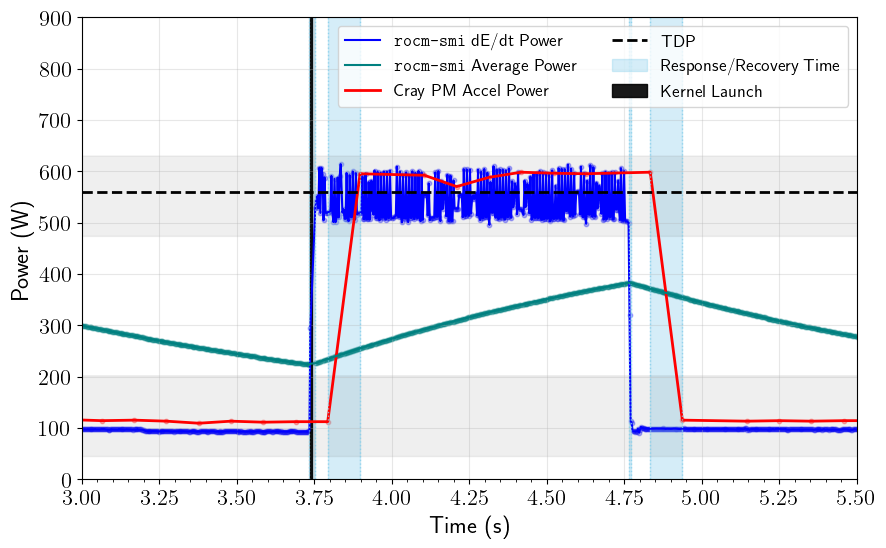

Processing key: A2rocm_smi:::energy_count:device=1
Processing 2365 labels for rising/falling regions.
Processing key: A2coretemp:::craypm:accel1_power
Processing 140 labels for rising/falling regions.
Processing key: A2rocm_smi:::current_socket_power:device=1


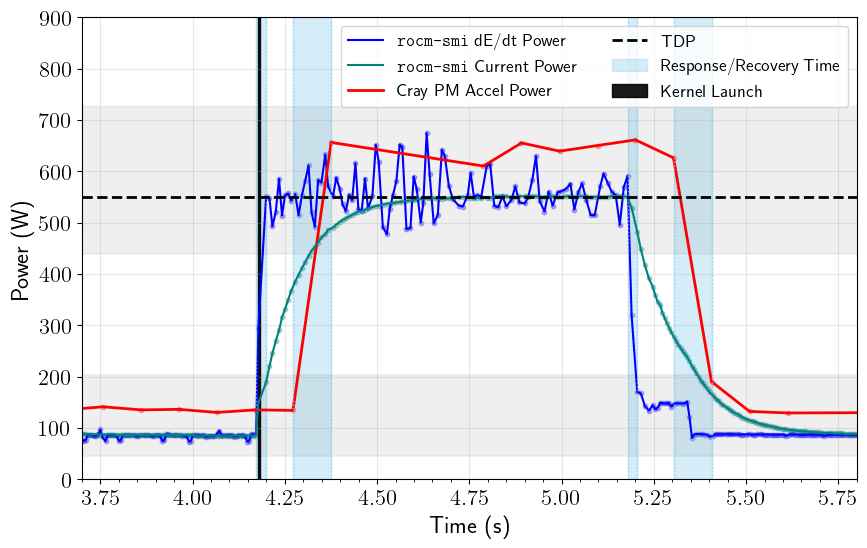

In [17]:
Label = Literal["rising", "falling", "peak", "trough"]


def count_periods(labels: List[Label]) -> int:
    count = 0
    last_label = ""
    for label in labels:
        if label in ("peak", "trough") and label != last_label:
            # print(f"Detected {label} region.")
            count += 1
            last_label = label
    return count

def label_by_fixed_bands_xy(
    x: Optional[List[float]],
    y: List[float],
    high_band_frac: float = 1/4,     # each plateau band takes this fraction of (max-min)
    low_band_frac: float = 1/4,     # each plateau band takes this fraction of (max-min)
    min_trough_run: int = 1,    # squash trough runs shorter than this
    min_peak_run: int = 1       # squash peak runs shorter than this
) -> List[Label]:
    """
    Amplitude-only labels using fixed bands from [min(y), max(y)].

    trough: y <= ymin + band_frac*(ymax - ymin)
    peak:   y >= ymax - band_frac*(ymax - ymin)
    middle: everything else -> 'rising'/'falling' based on surrounding plateaus.
    """
    n = len(y)
    if x is not None and len(x) != n:
        raise ValueError("x and y must have the same length when x is provided.")
    if n == 0:
        return []
    if n == 1:
        return ["peak"]

    # Preserve order (sort by time if provided)
    order = np.argsort(x) if x is not None else np.arange(n)
    inv = np.empty_like(order); inv[order] = np.arange(n)
    y_arr = np.asarray(y, float)[order]
    m = len(y_arr)

    # ymin = float(np.min(y_arr))
    # ymax = float(np.max(y_arr))
    
    # Use 99th and 1st percentiles to avoid outlier influence
    ymin = float(np.percentile(y_arr, 1))
    ymax = float(np.percentile(y_arr, 99))
    
    yr = ymax - ymin
    if yr <= 0.0:
        return ["peak"] * n  # flat signal ⇒ arbitrary single plateau

    # Ensure bands don't overlap (cap band_frac at < 0.5)
    # high_bf = float(np.clip(high_band_frac, 0.0, 0.49))
    # low_bf = float(np.clip(low_band_frac, 0.0, 0.49))
    high_bf = high_band_frac
    low_bf = low_band_frac
    thr_low  = ymin + low_bf * yr
    thr_high = ymax - high_bf * yr
    
    is_trough = y_arr <= thr_low
    is_peak   = y_arr >= thr_high
    # If any point is somehow both (numerical tie), prefer the closer side
    both = is_trough & is_peak
    if both.any():
        closer_peak = (y_arr[both] - thr_high) <= (thr_low - y_arr[both])
        is_peak[both] = closer_peak
        is_trough[both] = ~closer_peak

    # Simple run squashing
    def squash(mask: np.ndarray, min_run: int) -> np.ndarray:
        if min_run <= 1:
            return mask
        out = mask.copy()
        i = 0
        while i < len(out):
            if out[i]:
                j = i
                while j < len(out) and out[j]:
                    j += 1
                if (j - i) < min_run:
                    out[i:j] = False
                i = j
            else:
                i += 1
        return out

    is_trough = squash(is_trough, min_trough_run)
    is_peak   = squash(is_peak,   min_peak_run)

    # Fill middle band using the sandwich rule
    labels = np.array(["rising"] * m, dtype=object)
    labels[is_trough] = "trough"
    labels[is_peak]   = "peak"

    left = np.full(m, "", dtype=object)
    right = np.full(m, "", dtype=object)

    last = ""
    for i in range(m):
        if labels[i] in ("peak", "trough"):
            last = labels[i]
        left[i] = last

    last = ""
    for i in range(m-1, -1, -1):
        if labels[i] in ("peak", "trough"):
            last = labels[i]
        right[i] = last

    for i in range(m):
        if labels[i] in ("peak", "trough"):
            continue
        L, R = left[i], right[i]
        if L == "trough" and R == "peak":
            labels[i] = "rising"
        elif L == "peak" and R == "trough":
            labels[i] = "falling"
        elif L == "peak" and R == "peak":
            labels[i] = "peak"
        elif L == "trough" and R == "trough":
            labels[i] = "trough"
        elif L == "peak" and R == "":
            labels[i] = "falling"
        elif L == "trough" and R == "":
            labels[i] = "rising"
        else:
            # no context at one edge: bias by proximity to thresholds
            labels[i] = "rising" if abs(y_arr[i] - thr_high) < abs(y_arr[i] - thr_low) else "falling"

    return labels[inv].tolist()

def run_to_signal_xy(
    run: Run,
    key: str,
    node: str = 'node0',
    differentiate: bool = True,
    apply_filter: bool = False
) -> Tuple[np.ndarray, np.ndarray]:
    samples = run.get_metric_samples(node, key)
    if 'rocm' in key.lower():
        # Just use the energy count timestamps
        energy_samples = run.get_metric_samples(node, 'A2rocm_smi:::energy_count:device=0')
        signal_x = np.array(energy_samples['Time'])
    elif 'craypm' in key.lower():
        # Use the craypm energy timestamps
        energy_samples = run.get_metric_samples(node, 'A2coretemp:::craypm:accel0_energy')
        signal_x = np.array(energy_samples['Time'])
    else:
        signal_x = np.array(samples['Time'])
    
    if 'power' in key.lower():
        signal_f = sampled_to_continuous(samples, linear_interpolate=False)
    else:
        signal_f = sampled_to_continuous(samples)
    # if apply_filter:
    #     signal_f = continuous_median_filter(signal_f, kernel_size=13)
    if differentiate:
        signal_f = numerical_derivative(signal_f, h=0.0005)
    if apply_filter:
        signal_f = continuous_median_filter(signal_f, kernel_size=13)
        # pass
    signal_y = np.array(signal_f(signal_x))
    return signal_x, signal_y

def run_to_event_labels(
    run: Run,
    key: str,
    differentiate: bool = True,
    apply_filter: bool = False,
    high_band_frac: float = 0.25,
    low_band_frac: float = 0.25,
    **label_kwargs
) -> List[Label]:
    signal_x, signal_y = run_to_signal_xy(
        run,
        key,
        differentiate=differentiate,
        apply_filter=apply_filter
    )
    labels = label_by_fixed_bands_xy(
        x=signal_x,
        y=signal_y,
        high_band_frac=high_band_frac,
        low_band_frac=low_band_frac,
        **label_kwargs
    )
    return labels

def run_to_label_bands(
    run: Run,
    key: str,
    differentiate: bool = True,
    apply_filter: bool = False,
    **label_kwargs
) -> Dict[Label, Tuple[float, float]]:
    signal_x, signal_y = run_to_signal_xy(
        run,
        key,
        differentiate=differentiate,
        apply_filter=apply_filter
    )
    labels = label_by_fixed_bands_xy(
        x=signal_x,
        y=signal_y,
        **label_kwargs
    )
    bands: Dict[Label, Tuple[float, float]] = {}
    unique_labels = set(labels)
    for label in unique_labels:
        indices = np.array([l == label for i, l in enumerate(labels)])
        if not np.any(indices):
            continue
        y_label = signal_y[indices]
        bands[label] = (float(np.min(y_label)), float(np.max(y_label)))
    return bands

def plot_events(
    run: Run,
    keys: List[str] = ['A2rocm_smi:::energy_count:device=0'],
    differentiate_rocm: bool = True,
    apply_filter: bool = False,
    vt_min: float = 3.5,
    vt_max: float = 5.5,
    tdp: float = 560.0,
    title: str = 'GPU Power Transition Events'
):
    plt.figure(figsize=(10, 6))
    # plt.title(title)
    plt.xlabel('Time (s)')
    plt.ylabel('Power (W)')
    plt.xlim(vt_min, vt_max)
    plt.ylim(0, None)
    
    
    line_colors = ['blue', 'red', 'teal', 'green', 'cyan', 'orange']
    for key, color in zip(keys, line_colors):
        print(f"Processing key: {key}")
        signal_x, signal_y = run_to_signal_xy(
            run,
            key,
            differentiate=differentiate_rocm and 'rocm' in key.lower() and 'power' not in key.lower(),
            apply_filter=apply_filter == True or str(apply_filter) in key.lower()
        )
        labels = run_to_event_labels(
            run,
            key,
            differentiate=differentiate_rocm and 'rocm' in key.lower() and 'power' not in key.lower(),
            apply_filter=apply_filter == True or str(apply_filter) in key.lower()
        )
        plt.plot(signal_x, signal_y, lw=2 if 'cray' in key.lower() else 1.5, label=(r'$\texttt{rocm-smi}$ dE/dt' if 'energy_count' in key.lower() else r'$\texttt{rocm-smi}$ Average' if 'power_average' in key.lower() else r'$\texttt{rocm-smi}$ Current' if 'current_socket_power' in key.lower() else 'Cray PM Accel') + ' Power', color=color)

        plt.scatter(signal_x, signal_y, color=color, s=10, alpha=0.3)

        if 'power_average' in key.lower() or 'current_socket_power' in key.lower():
            # Skip event plotting for average power signals
            continue

        # Filter for the peaks
        peak_indices = [i for i, label in enumerate(labels) if label == "peak"]
        trough_indices = [i for i, label in enumerate(labels) if label == "trough"]
        rising_indices = [i for i, label in enumerate(labels) if label == "rising"]
        falling_indices = [i for i, label in enumerate(labels) if label == "falling"]
        # Now show rising and falling durations
        rising_regions = []
        falling_regions = []
        n = len(labels)
        print(f"Processing {n} labels for rising/falling regions.")
        i = 0
        while i < n:
            if labels[i] == "trough":
                # Find the next peak
                j = i + 1
                while j < n and labels[j] != "peak":
                    j += 1
                if j < n:
                    # We found a peak at j
                    # Now find the last trough before j
                    k = j - 1
                    while k > i and labels[k] != "trough":
                        k -= 1
                    if k >= i:
                        rising_regions.append((signal_x[k], signal_x[j]))
                    i = j + 1
                else:
                    break
            elif labels[i] == "peak":
                # Find the next trough
                j = i + 1
                while j < n and labels[j] != "trough":
                    j += 1
                if j < n:
                    # We found a trough at j
                    # Now find the last peak before j
                    k = j - 1
                    while k > i and labels[k] != "peak":
                        k -= 1
                    if k >= i:
                        falling_regions.append((signal_x[k], signal_x[j]))
                    i = j + 1
                else:
                    break
            else:
                i += 1
            
        for start, end in rising_regions:
            plt.axvspan(start, end, color='skyblue', alpha=0.35, label='Response/Recovery Time')
        for start, end in falling_regions:
            plt.axvspan(start, end, color='skyblue', alpha=0.35, label='Response/Recovery Time')
        # Use vertical lines instead of shaded regions
        for start, end in rising_regions:
            plt.axvline(start, color='skyblue', ls=':', lw=1, alpha=0.8)
            plt.axvline(end, color='skyblue', ls=':', lw=1, alpha=0.8)
        for start, end in falling_regions:
            plt.axvline(start, color='skyblue', ls=':', lw=1, alpha=0.8)
            plt.axvline(end, color='skyblue', ls=':', lw=1, alpha=0.8)

    # Plot the bands
    bands = [run_to_label_bands(
        run,
        key,
        differentiate=differentiate_rocm and 'rocm' in key.lower(),
        apply_filter=apply_filter == True or str(apply_filter) in key.lower()
    ) for key in keys if not ('power_average' in key.lower() or 'current_socket_power' in key.lower())]
    # Find the minimum and maximum across all bands
    combined_bands: Dict[Label, Tuple[float, float]] = {}
    for band_dict in bands:
        for label, (ymin, ymax) in band_dict.items():
            if label not in combined_bands:
                combined_bands[label] = (ymin, ymax)
            else:
                cur_ymin, cur_ymax = combined_bands[label]
                combined_bands[label] = (min(cur_ymin, ymin), max(cur_ymax, ymax))
    bands = combined_bands
    bands = {k: v for k, v in bands.items() if k in ('peak', 'trough')}
    for label, (ymin, ymax) in bands.items():
        plt.fill_between(signal_x, ymin, ymax, alpha=0.1,
                         label=f'{label.capitalize()} Band', color=
                         'dimgray' if label == 'peak' else 'dimgray')
        # Use horizontal lines instead of filled bands
        # plt.hlines(ymin, vt_min, vt_max, colors=
        #             'blue' if label == 'peak' else 'magenta',
        #                 linestyles='--', lw=1, label=f'{label.capitalize()} Band (min)')
        # plt.hlines(ymax, vt_min, vt_max, colors=
        #                 'blue' if label == 'peak' else 'magenta',
        #                 linestyles='-.', lw=1, label=f'{label.capitalize()} Band (max)')
    calls_to_mpi = ['MPI_Barrier']
    calls_to_hip = ['hipLaunchKernel', '__hipLaunchKernel']
    call_graph_df = run.nodes[0].ranks[0].call_graph
    call_graph_df = call_graph_df[(call_graph_df['Start Time'] >= vt_min) & (call_graph_df['Start Time'] <= vt_max)]
    call_graph_df = call_graph_df[call_graph_df['Name'].isin(calls_to_mpi + calls_to_hip)]
    last_func = -1
    for _, row in call_graph_df.iterrows():
        if row['End Time'] < vt_min or row['Start Time'] > vt_max:
            continue
        if last_func >= 0 and row['Start Time'] - last_func < 2.0:
            continue
        center = row['Start Time']
        # Center the shaded region around the start time with a fixed width of 3 ms
        start = center - 0.0025
        end =   center + 0.0025
        plt.axvspan(start, end, color='black', alpha=0.9, label='Kernel Launch')
        
        last_func = row['Start Time']
    # Draw a dashed line for the TDP
    plt.axhline(tdp, color='black', ls='--', lw=2, label='TDP')

    handles, labels = plt.gca().get_legend_handles_labels()

    # Remove duplicates by creating an ordered dict
    from collections import OrderedDict
    by_label = OrderedDict(zip(labels, handles))

    # Sort the legend entries
    # by_label = OrderedDict(sorted(by_label.items(), key=lambda x: x[0]))
    desired_order = [
        r'$\texttt{rocm-smi}$ dE/dt Power',
        r'$\texttt{rocm-smi}$ Average Power',
        r'$\texttt{rocm-smi}$ Current Power',
        'Cray PM Accel Power',
        'TDP',
        'Peak',
        'Trough',
        'Rising',
        'Falling',
        'Response Time',
        'Recovery Time',
        'Response/Recovery Time',
        'Rising Duration',
        'Falling Duration',
        'Rising Duration Start',
        'Rising Duration End',
        'Falling Duration Start',
        'Falling Duration End',
        'Peak Band (min)',
        'Peak Band (max)',
        'Trough Band (min)',
        'Trough Band (max)',
        'Kernel Launch'
    ]
    by_label = OrderedDict((k, by_label[k]) for k in desired_order if k in by_label)
    plt.legend(by_label.values(), by_label.keys(), loc='upper right', ncol=2)
    plt.grid(alpha=0.3)
    # plt.xticks(np.arange(vt_min, vt_max + 0.1, 0.1))
    major_ticker = MultipleLocator(0.25)
    plt.gca().xaxis.set_major_locator(major_ticker)
    minor_ticker = MultipleLocator(0.05)
    plt.gca().xaxis.set_minor_locator(minor_ticker)


    # Make it use 10 ticks for the y axis
    plt.yticks([0, 100, 200, 300, 400, 500, 600, 700, 800, 900])
    # Use MajorLocator to set y ticks
    plt.savefig(title.replace(' ', '_') + '.png', dpi=600)
    plt.show()



plot_events(
    double_gcd_runs[(1000, 1000)].runs[0],
    ['A2rocm_smi:::energy_count:device=0', 'A2coretemp:::craypm:accel0_power', 'A2rocm_smi:::power_average:device=0:sensor=0'],
    apply_filter='energy_count',
    # vt_min=6.0,
    # vt_max=8.0,
    vt_min=3.0,
    vt_max=5.5,
    tdp=560,
    title='MI250X GPU Response To Workload Changes'
    # title='GPU Power Transition Events (MI250X)'
)

plot_events(
    apu_runs[(1000, 1000)].runs[5],
    ['A2rocm_smi:::energy_count:device=1', 'A2coretemp:::craypm:accel1_power', 'A2rocm_smi:::current_socket_power:device=1'],
    apply_filter='energy_count',
    # vt_min=6.0,
    # vt_max=8.0,
    vt_min=3.7,
    vt_max=5.8,
    tdp=550,
    title='MI300A APU Response To Workload Changes'
)

In [18]:
# Get the end time of the notebook
NOTEBOOK_END_TIME = time.time()
print(f"Notebook end time: {NOTEBOOK_END_TIME}")
print(f"Notebook end at {NOTEBOOK_END_TIME} ({datetime.datetime.fromtimestamp(NOTEBOOK_END_TIME)})")

NOTEBOOK_DURATION = NOTEBOOK_END_TIME - NOTEBOOK_START_TIME
print(f"Notebook execution time: {NOTEBOOK_DURATION:.2f} seconds")

Notebook end time: 1766157984.5912197
Notebook end at 1766157984.5912197 (2025-12-19 10:26:24.591220)
Notebook execution time: 282.27 seconds
